# Perumusan Masalah 


### A. Latar Belakang Masalah
Dalam industri real estat, menentukan harga jual yang wajar dari sebuah properti sering kali menjadi tantangan yang kompleks. Harga sebuah rumah tidak hanya ditentukan oleh tebakan semata, melainkan dipengaruhi oleh berbagai faktor fisik bangunan seperti luas area, jumlah kamar tidur, dan bahkan usia bangunan. Kesalahan dalam menetapkan harga dapat mengakibatkan kerugian finansial atau membuat properti tidak kunjung laku di pasar. Oleh karena itu, diperlukan sebuah pendekatan berbasis data (*data-driven*) menggunakan **Machine Learning** untuk mengestimasi harga wajar rumah secara objektif.


### B. Rumusan Masalah
Berdasarkan latar belakang di atas, rumusan masalah dalam proyek ini adalah:

- **(Univariat):** Bagaimana pengaruh luas bangunan (*sqft_lot*) terhadap harga jual sebuah rumah?
- **(Multivariat):** Apakah penggabungan beberapa fitur sekaligus (seperti luas bangunan, tahun dibangun, dan jumlah kamar tidur dan kamar mandi, banyak lantai) dapat meningkatkan akurasi prediksi harga rumah dibandingkan hanya menggunakan satu fitur?
- **(Polinomial):** Mengingat nilai properti sering kali memiliki pola yang tidak linear terhadap usianya (misalnya harga turun saat rumah mulai menua, namun bisa naik kembali jika menjadi rumah klasik/bersejarah), apakah penggunaan **Regresi Polinomial** dapat menangkap pola tersebut dengan lebih baik daripada regresi linear biasa?


### C. Tujuan Pemodelan
Tujuan dari proyek ini adalah:

- Membangun model **Regresi Univariat**, **Regresi Multivariat**, dan **Regresi Polinomial** untuk memprediksi harga rumah menggunakan dataset publik berbasis data nyata dari *Kaggle.com*.
- Memproses dan menyaring data mentah untuk memastikan kualitas pemodelan (menggunakan 300 sampel data yang memenuhi standar kelayakan).
- Mengevaluasi dan membandingkan kinerja dari ketiga model tersebut menggunakan metrik regresi yang komprehensif, yaitu **MSE (Mean Squared Error)**, **RMSE (Root Mean Squared Error)**, **MAE (Mean Absolute Error)**, dan **R² (R-Squared)** untuk menemukan model prediksi yang paling optimal.

---

# Importing all the libraries

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pre-processing Data


In [3]:
df_raw = pd.read_csv('Housing.csv')

# changing the non-numerical into numerical
df_raw['date'] = pd.to_datetime(df_raw['date']).dt.date

# filtering column and sample datas
df_kondisi = df_raw[df_raw['waterfront'] == 0 ]
df_new = df_kondisi[['date', 'price', 'bedrooms','bathrooms', 'sqft_living', 'sqft_lot','floors', 'view', 'condition', 'grade', 'yr_built']]
df_final = df_new.head(300)

# converting into new file .csv
df_final.to_csv('dataset_housing-price.csv', index=False)
print("Done, size:", df_final.shape)

Done, size: (300, 11)


Read and Display Data

In [4]:
df_housing = pd.read_csv('dataset_housing-price.csv')
print(df_housing)

           date     price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0    2014-10-13  231300.0         2       1.00         1180      5650     1.0   
1    2014-12-09  538000.0         3       2.25         2570      7242     2.0   
2    2015-02-25  180000.0         2       1.00          770     10000     1.0   
3    2014-12-09  604000.0         4       3.00         1960      5000     1.0   
4    2015-02-18  510000.0         3       2.00         1680      8080     1.0   
..          ...       ...       ...        ...          ...       ...     ...   
295  2014-05-29  267500.0         3       1.75         1590     11914     1.0   
296  2014-08-11  335000.0         3       2.50         2440      7632     2.0   
297  2014-06-19  576000.0         3       2.50         1940      9000     1.0   
298  2015-04-01  208633.0         3       2.50         2040      3810     2.0   
299  2015-01-15  315000.0         3       2.25         2200      8750     1.0   

     view  condition  grade

In [5]:
df_housing = df_housing.drop(['date'], axis = 1)

Cleaning Data

In [6]:
df_housing.drop_duplicates()
df_housing.dropna()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,yr_built
0,231300.0,2,1.00,1180,5650,1.0,0,3,7,1955
1,538000.0,3,2.25,2570,7242,2.0,0,3,7,1951
2,180000.0,2,1.00,770,10000,1.0,0,3,6,1933
3,604000.0,4,3.00,1960,5000,1.0,0,5,7,1965
4,510000.0,3,2.00,1680,8080,1.0,0,3,8,1987
...,...,...,...,...,...,...,...,...,...,...
295,267500.0,3,1.75,1590,11914,1.0,2,3,7,1957
296,335000.0,3,2.50,2440,7632,2.0,0,3,8,1998
297,576000.0,3,2.50,1940,9000,1.0,0,4,7,1948
298,208633.0,3,2.50,2040,3810,2.0,0,3,8,2006


---

# Visualisasi Data

### 1. Describe

In [7]:
display(df_housing .describe())

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,yr_built
count,3.000000e+02,300.000000,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000
mean,5.002072e+05,3.336667,2.020833,2055.920000,13974.660000,1.42500,0.180000,3.450000,7.586667,1966.976667
std,3.209589e+05,0.832044,0.726199,875.653415,27031.807165,0.50271,0.670147,0.670072,1.073778,28.158464
min,1.530000e+05,1.000000,0.750000,700.000000,1044.000000,1.00000,0.000000,1.000000,5.000000,1900.000000
25%,2.958750e+05,3.000000,1.500000,1370.000000,5123.750000,1.00000,0.000000,3.000000,7.000000,1949.750000
50%,4.300000e+05,3.000000,2.000000,1965.000000,8077.500000,1.00000,0.000000,3.000000,7.000000,1968.000000
75%,5.983125e+05,4.000000,2.500000,2452.500000,11090.000000,2.00000,0.000000,4.000000,8.000000,1989.000000
max,2.900000e+06,6.000000,4.750000,5420.000000,315374.000000,3.00000,4.000000,5.000000,12.000000,2014.000000


### 2. Info

In [8]:
display(df_housing .info())

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        300 non-null    float64
 1   bedrooms     300 non-null    int64  
 2   bathrooms    300 non-null    float64
 3   sqft_living  300 non-null    int64  
 4   sqft_lot     300 non-null    int64  
 5   floors       300 non-null    float64
 6   view         300 non-null    int64  
 7   condition    300 non-null    int64  
 8   grade        300 non-null    int64  
 9   yr_built     300 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 23.6 KB


None

### 3. ScatterPlot

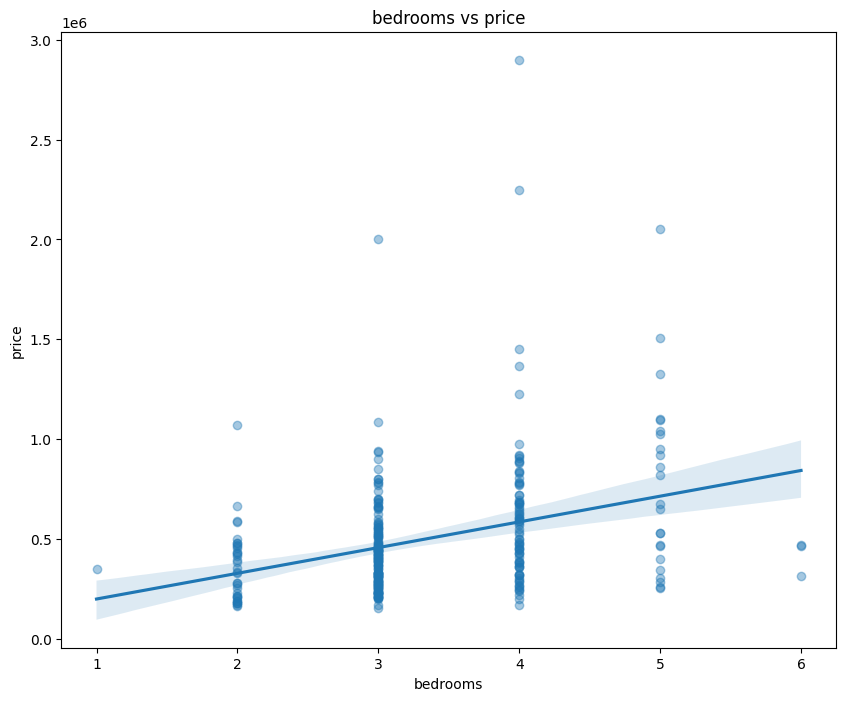

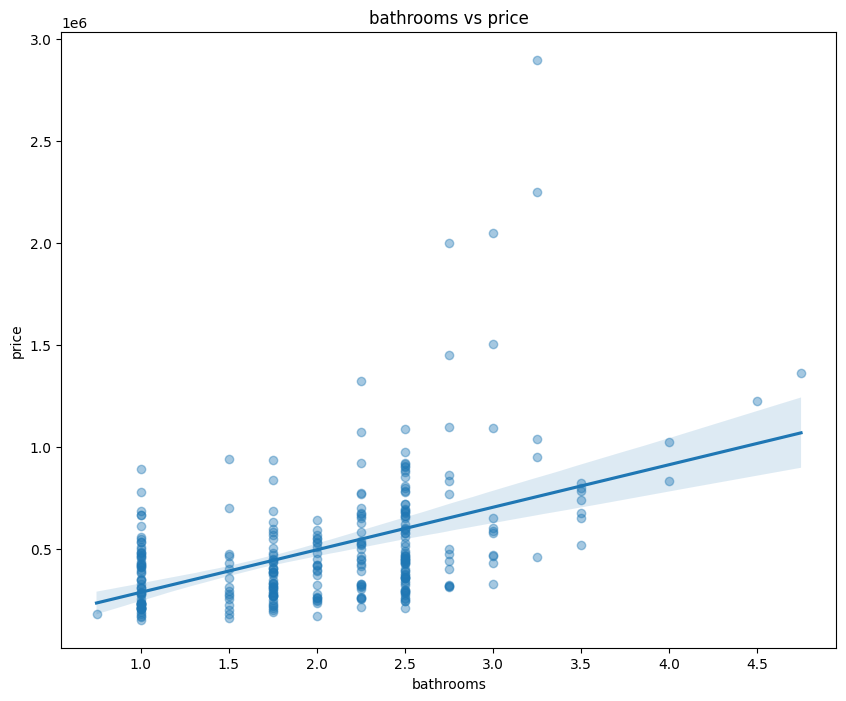

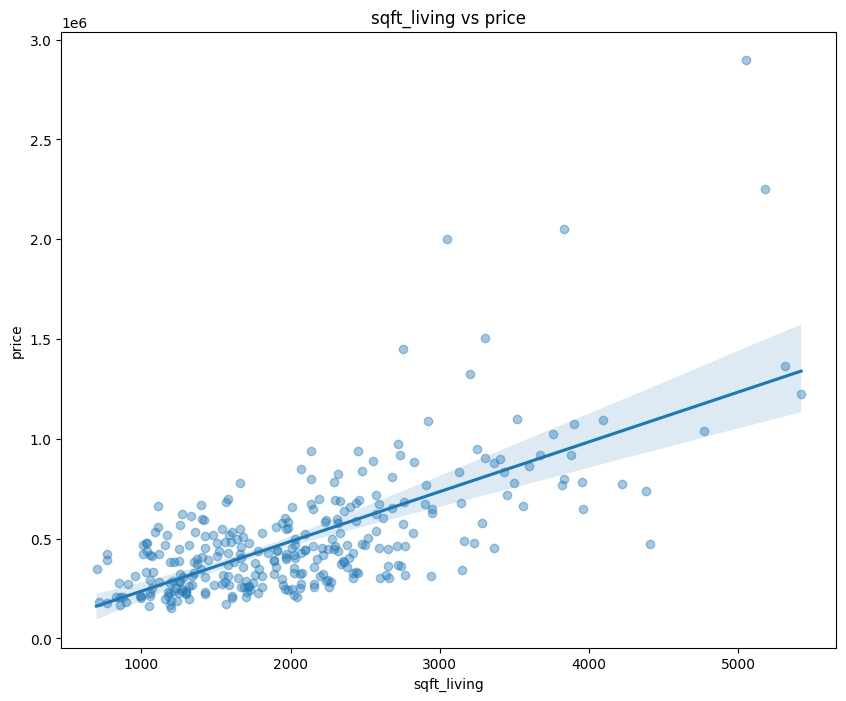

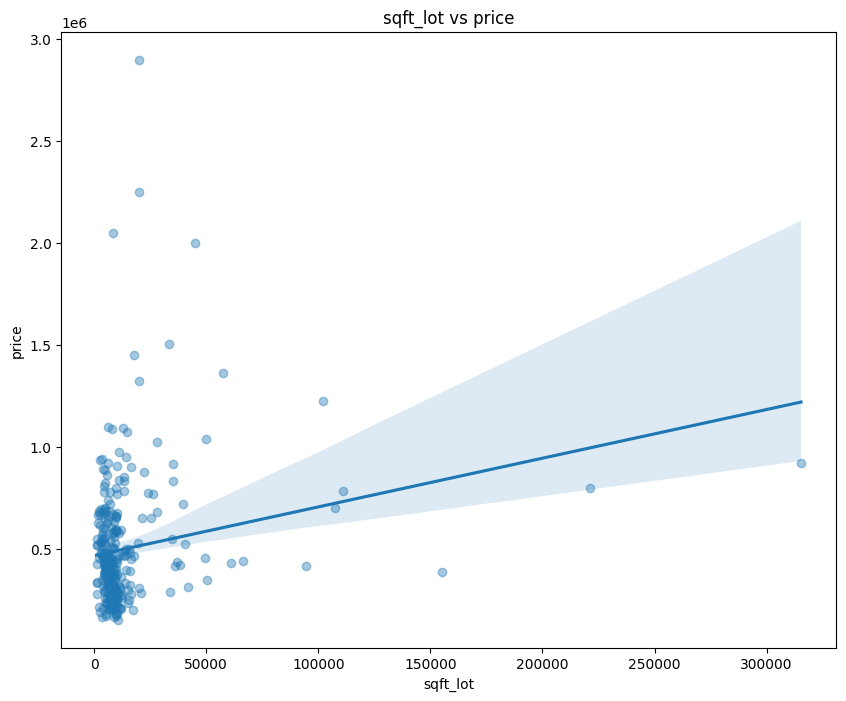

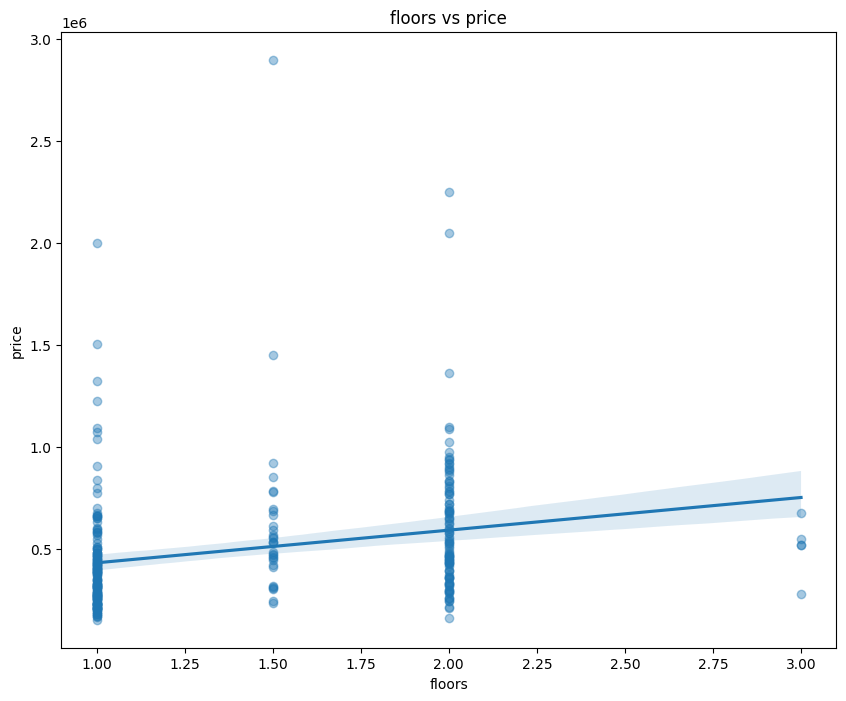

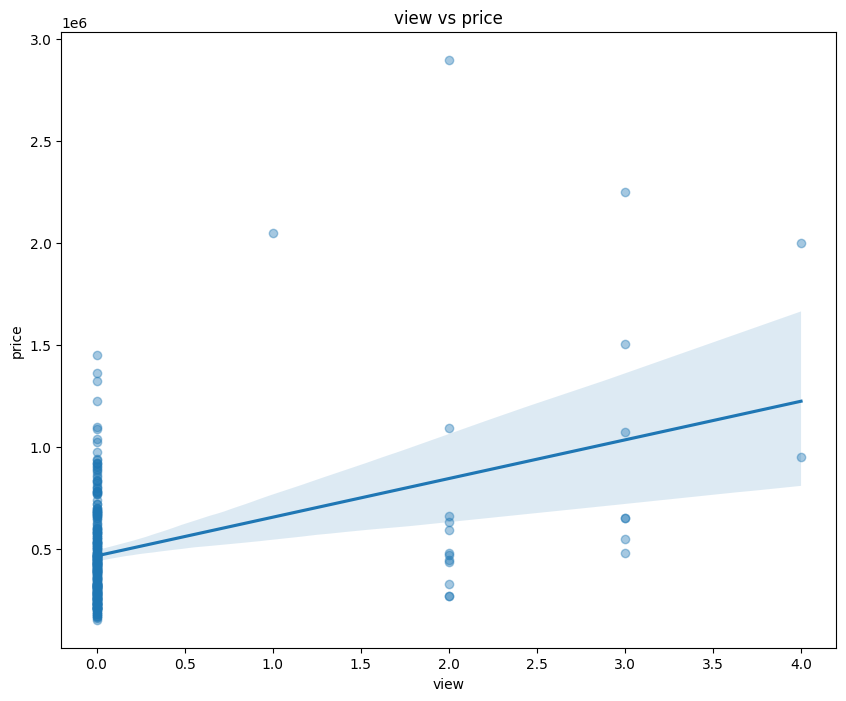

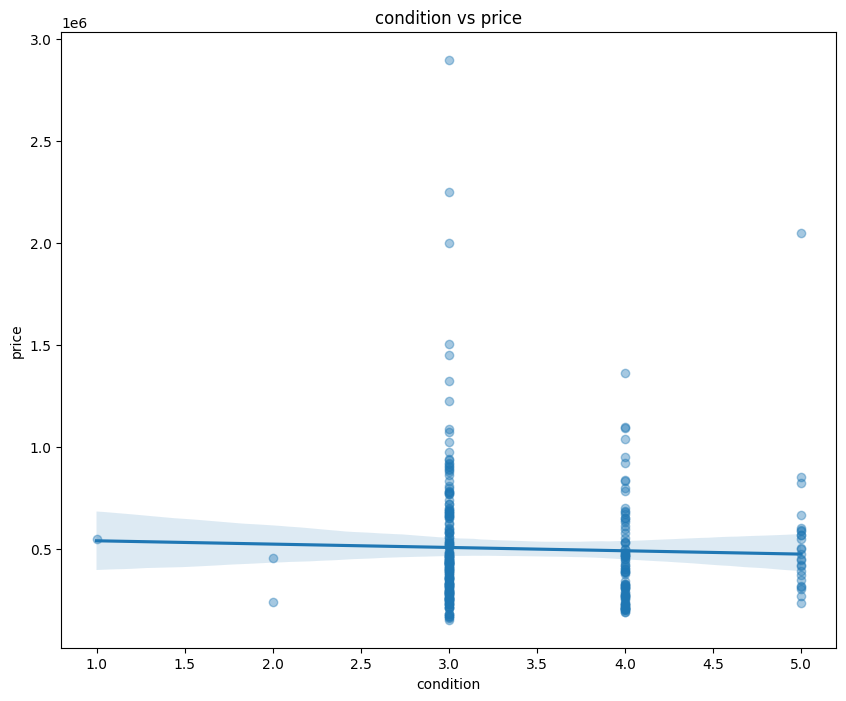

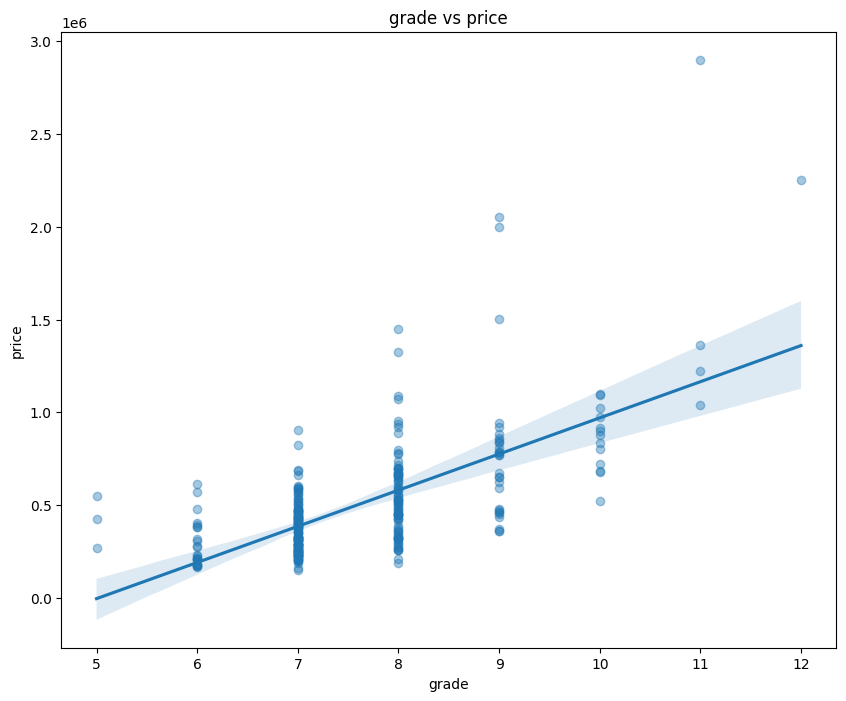

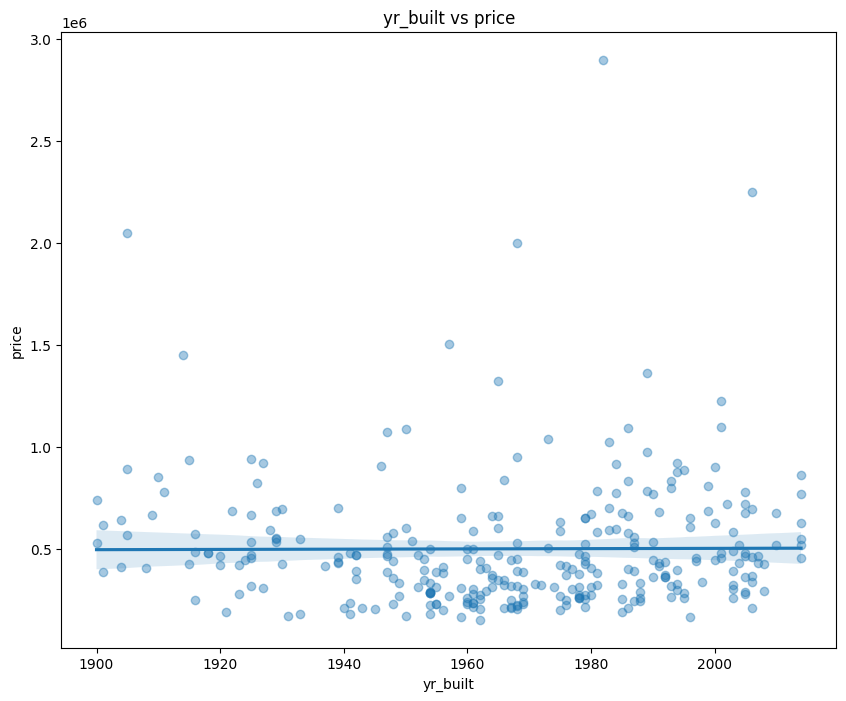

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['bedrooms','bathrooms', 'sqft_living', 'sqft_lot','floors', 'view', 'condition', 'grade', 'yr_built']

for f in features:
    plt.figure(figsize=(10,8))
    sns.regplot(x=f, y='price', data=df_housing,
                scatter_kws={'alpha':0.4})
    plt.title(f"{f} vs price")
    plt.show()

---

# Implementasi Model

- Fitur Numerik

In [10]:
df_numeric = df_housing.select_dtypes(include=np.number)
df_numeric.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,yr_built
0,231300.0,2,1.00,1180,5650,1.0,0,3,7,1955
1,538000.0,3,2.25,2570,7242,2.0,0,3,7,1951
2,180000.0,2,1.00,770,10000,1.0,0,3,6,1933
3,604000.0,4,3.00,1960,5000,1.0,0,5,7,1965
4,510000.0,3,2.00,1680,8080,1.0,0,3,8,1987


In [11]:
features = ['bedrooms','bathrooms', 'sqft_living', 'sqft_lot','floors', 'view', 'condition', 'grade', 'yr_built']
target = "price"

X = df_numeric[features]
y = df_numeric[target]

- Split Data

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

# Pra-Pemrosesan Data (Scaling)

In [13]:
scaler = StandardScaler() 

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

---

# Evaluasi Model

- Regresi Univariat

In [14]:
X_uni = df_numeric[["sqft_living"]] 
y_uni = df_numeric[["price"]] 

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_uni, y_uni, test_size = 0.2, random_state=42
) 


model_uni = LinearRegression()
model_uni.fit(X_train_u, y_train_u) 

y_pred_uni = model_uni.predict(X_test_u)

In [15]:
mse_uni = mean_squared_error(y_test_u, y_pred_uni)
rmse_uni = np.sqrt(mse_uni)
mae_uni = mean_absolute_error(y_test_u, y_pred_uni)
r2_uni = r2_score(y_test_u, y_pred_uni)

print("==== REGRESI UNIVARIAT ====")
print("MSE: ", mse_uni)
print("RMSE: ", rmse_uni)
print("MAE: ", mae_uni)
print("R2: ", r2_uni)

==== REGRESI UNIVARIAT ====
MSE:  71026450834.23033
RMSE:  266507.88137357275
MAE:  160410.35735840257
R2:  0.5758633422558608


- Regresi Multivariat

In [16]:
model_multi = LinearRegression() 
model_multi.fit(X_train_scaled, y_train)

y_pred_multi = model_multi.predict(X_test_scaled) 

In [17]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
mae_multi = mean_absolute_error(y_test, y_pred_multi)
r2_multi = r2_score(y_test, y_pred_multi)

print("=== Regresi Multivariat ===")
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("MAE:", mae_multi)
print("R2:", r2_multi)

=== Regresi Multivariat ===
MSE: 46786667084.82722
RMSE: 216302.25862165014
MAE: 134294.99596571416
R2: 0.7206119639757813


- Regresi Polinomial

In [18]:
poly = PolynomialFeatures(degree=2) 

X_train_poly = poly.fit_transform(X_train_scaled) 
X_test_poly = poly.transform(X_test_scaled) 

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

In [19]:
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("=== Regresi Polinomial (degree=2) ===")
print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("MAE:", mae_poly)
print("R2:", r2_poly)

=== Regresi Polinomial (degree=2) ===
MSE: 130035229484.14607
RMSE: 360603.978741425
MAE: 191201.4472110853
R2: 0.22349058731486426


---

# Interpretasi Hasil

In [20]:
results = pd.DataFrame({
    "Model": ["Univariat", "Multivariat", "Polinomial"],
    "MSE": [mse_uni, mse_multi, mse_poly],
    "RMSE": [rmse_uni, rmse_multi, rmse_poly],
    "MAE": [mae_uni, mae_multi, mae_poly],
    "R2": [r2_uni, r2_multi, r2_poly]
})

results

,Model,MSE,RMSE,MAE,R2
0,Univariat,7.102645e+10,266507.881374,160410.357358,0.575863
1,Multivariat,4.678667e+10,216302.258622,134294.995966,0.720612
2,Polinomial,1.300352e+11,360603.978741,191201.447211,0.223491


## Kesimpulan

- Regresi multivariat menunjukkan performa terbaik dengan nilai R² sebesar 0.7206. Hal ini berarti 72% variasi harga rumah dapat dijelaskan oleh kombinasi fitur yang digunakan.

- Regresi univariat menggunakan satu variabel utama (`sqft_living`) sudah mampu menjelaskan 57% variasi harga, yang menunjukkan bahwa luas bangunan merupakan faktor dominan dalam penentuan harga rumah.

- Regresi polinomial menghasilkan R² sebesar 0.2234, yang paling rendah. Ini menunjukkan hubungan fitur dan harga rumah itu linear.

---

# **Komitmen Integritas**

*"Di hadapan TUHAN yang hidup, saya menegaskan bahwa saya tidak memberikan maupun menerima bantuan apapun-baik fisan, tulisan, maupun elektronik-di dalam ujian ini selain daripada apa yang telah diizinkan oleh pengajar, dan tidak akan menyebarkan baik soal maupun jawaban ujian kepada pihak lain."*


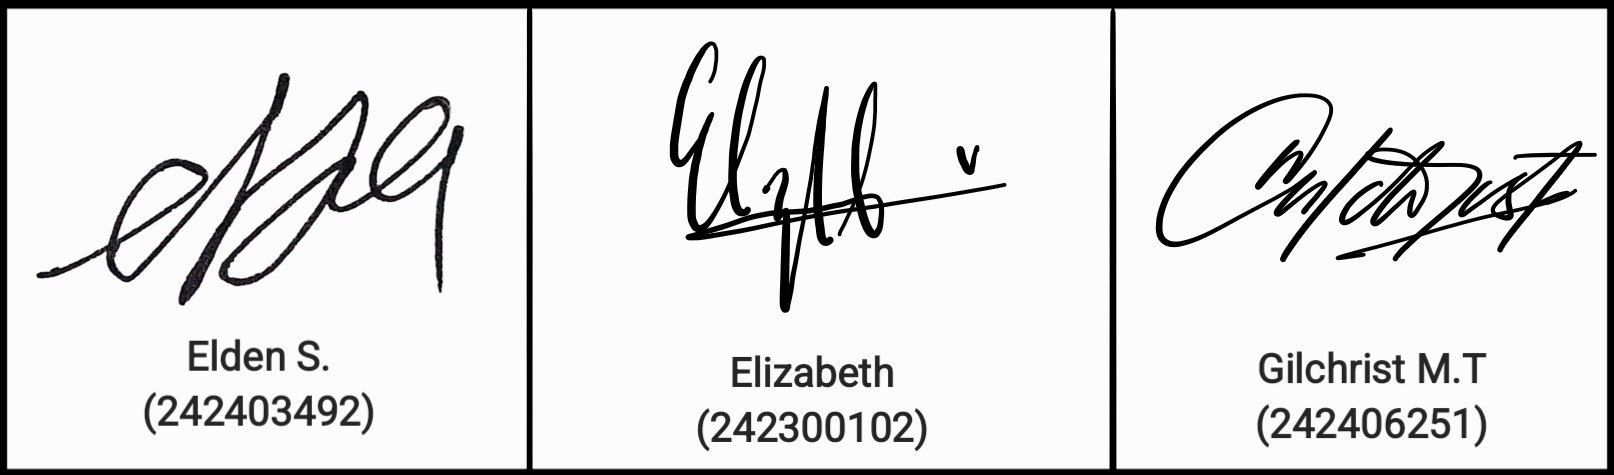